# Punto 1 


In [67]:
import numpy as np
import matplotlib.pylab as plt
from scipy.interpolate import interp1d

### Constantes y valores iniciales


In [ ]:
g = 9.81 # gravedad [m/s2]
P = 101325 # presión atmosferica [Pa]

# Datos 
z_data = np.array([0.10, 0.22, 0.78, 1.12]) # Altura [m]
T_data = np.array([550, 700, 1000, 850]) + 273.15 # Temperatura [K]

D_inf = 0.067 # diametro inferior [m]
D_sup = 0.081 # diametro superior [m]
#------------------------------
# particula
#------------------------------
dp = 150e-6 # diametro[m]
rho_p = 810 # densidad [kg/m3]
cp = 1.52e3 # capacidad calorifica aproximada [J/kg*K]

Vp = np.pi * dp**3 / 6 # volumen [m3]
Apf = np.pi * dp**2 / 4 # area frontal [m2]
Aps = np.pi * dp**2 # area superficial total [m2]
mp = rho_p * Vp # masa [kg] 

#------------------------------

# Flujo volumétrico inicial
Q_lpm = 230.5
Q0 =  Q_lpm / 1000 / 60  # L/min -> m3/s


t0 = 0.0 # Tiempo inicial [s]
tf = 1.0 #0.46270000000000006 # Tiempo final [s]

H0 = 0.10 #alruta minima [m]
Hf = 1.12 #altura maxima [m]

### Interpolación lineal temperatura (T)

In [69]:

Tg_func = interp1d(z_data, T_data, fill_value=(T_data[0], T_data[-1]),bounds_error=False)


### Propiedades del gas (N2)

In [70]:
M_N2   = 0.02802   # masa molar  kg/mol
R_u    = 8.314     # J/mol·K
# temperatura del gas en función de la altura
def T_g(z):
    return float(Tg_func(np.clip(z, 0.0 ,Hf)))

# Densidad en función de la temperatura
def rho_g(T):
    return P * M_N2/ (R_u * T)

# Viscosidad dinamica en función de la temperatura
def mu_g(T):
    mu0 = 1.663e-5
    T0 = 300
    S = 111
    return mu0 * (T/T0)**1.5 * (T0 + S)/(T + S)

# Conductividad termica en función de la temperatura
def k_g(T):
    k_ref = 0.0242   # W/m·K a 273.15 K
    T_ref = 273.15
    n     = 0.82
    return k_ref * (T / T_ref)**n

# Capasidad calorifica del gas
def cp_g(T):
    # Coeficientes en J/mol·K, rango 300-1000 K
    a = [29.105, -1.139e-3, 4.148e-6, -2.963e-9]
    cp_mol = a[0] + a[1]*T + a[2]*T**2 + a[3]*T**3   # J/mol·K
    return cp_mol / M_N2   # J/kg·K

# Numero de prandtl del gas
def pr_g(T):
    return mu_g(T) * cp_g(T) / k_g(T)

### Geometria del reactor

In [71]:
# Diametro reactor en función de la altura
def D_reactor(z):
    if z <= 0.40:
        return D_inf
    elif z < 0.60:
        return D_inf + (D_sup - D_inf)*(z - 0.40)/0.20
    else:
        return D_sup

# Area reactor en funcion de altura
def area(z):
    D = D_reactor(z)
    return np.pi * D**2 / 4

In [72]:
# Flujo masico del gas (constante)
mdot = rho_g(T_data[0]) * Q0

# Velocidad del gas en funcion de la altura y la temperatura
def u_g(z, T=None):
    if T is None:
        T = T_g(z)
    return (mdot / rho_g(T) ) / area(z)

In [73]:
def reynolds(v_rel, T):
    return rho_g(T) * abs(v_rel) * dp / mu_g(T)

def coeficiente_arrastre(Re):
    if Re < 1e-10:
        return 24.0 / max (Re, 1e-10)
    
    Re1 = Re

    p1 = (24 / Re1)**10 + 21**10
    q1 = p1**(1/10)
    p2 = (6 / Re1**(1/2))**10 + 0.4**10
    q2 = p2**(1/10)

    CD = ((q1**-10 + q2**-10)**(-1/10))

    if Re <= 1000:
        CD = 24/Re * (1 + 0.15 * Re**0.687)
    else:
        CD = 0.44
    return CD

In [74]:
#Coeficiente de transferencia del calor convectivo
def h_conv(v_rel, T):
    Re = reynolds(v_rel, T)
    Pr = pr_g(T)
    Nu = 2.0 +0.6 * Re**(0.5) * Pr**(1/3)
    k = k_g(T)
    return Nu * k / dp

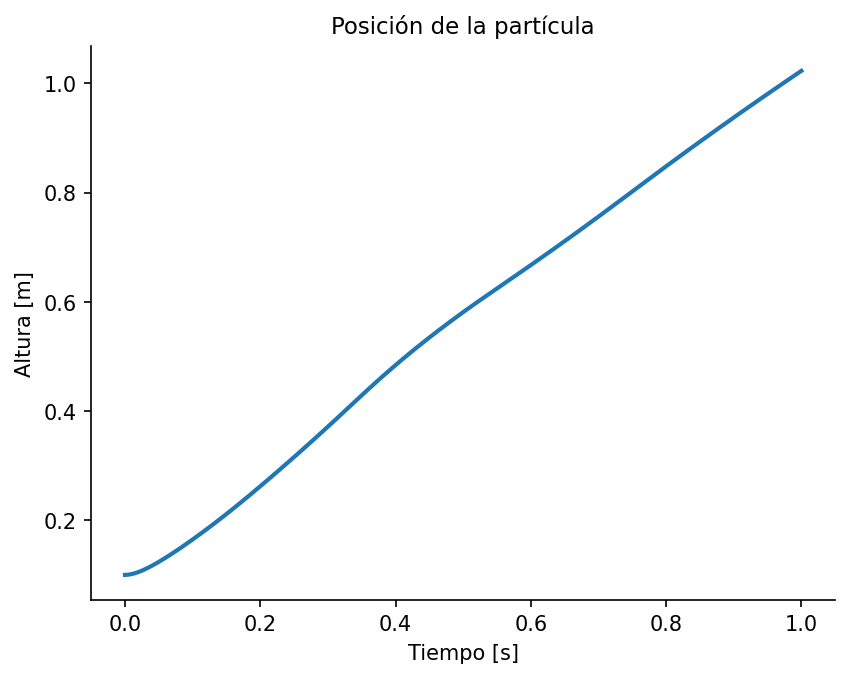

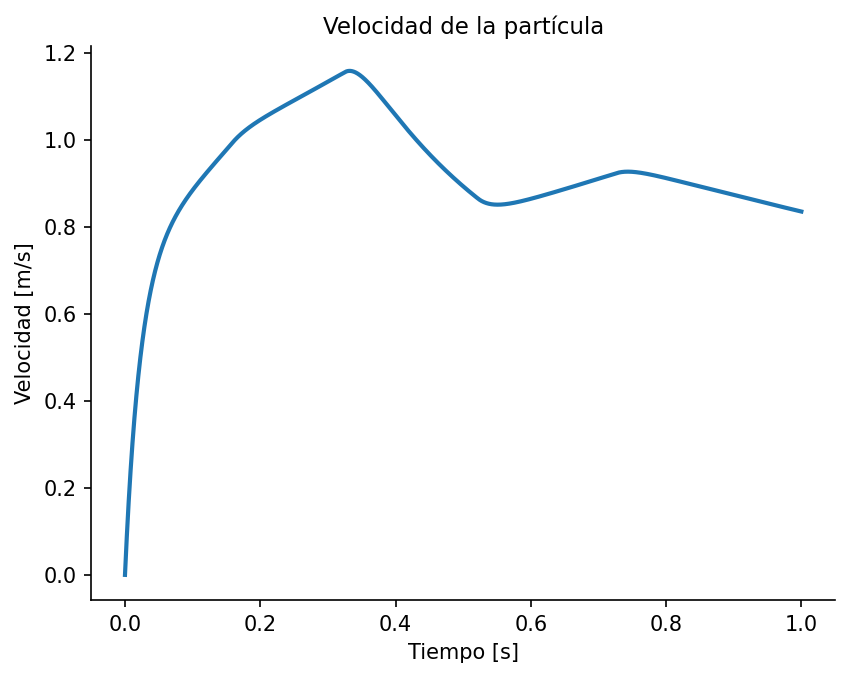

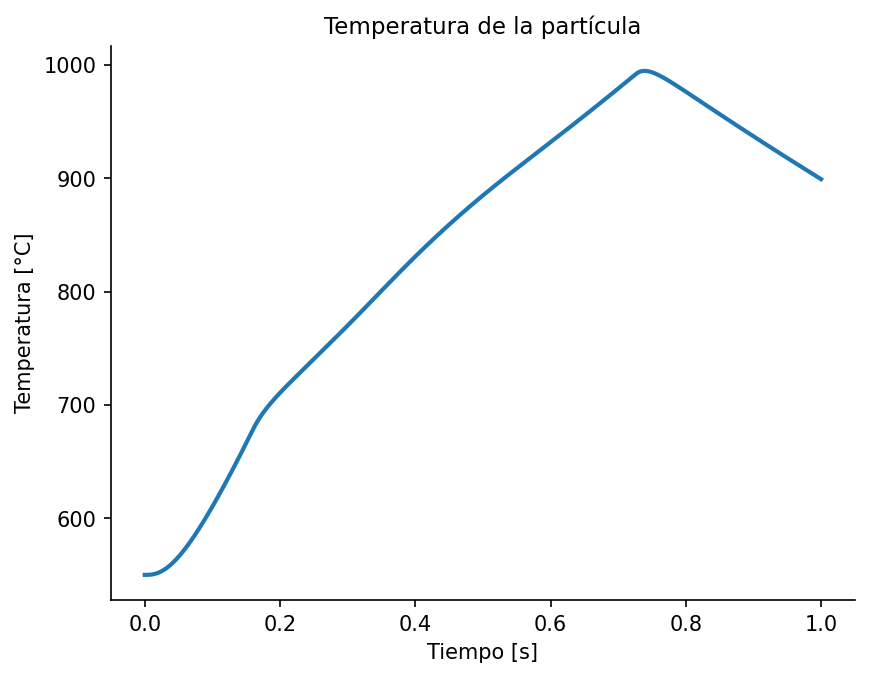

Temperatura máxima: 994.8294854933325 °C
Altura maxima:  1.0226913574571816 m


In [94]:
def modelo(t, y):
    
    z, v, Tp = y
    
    # Temperatura del gas en la altura actual
    Tg = T_g(z)
    
    # Propiedades del gas
    rho = rho_g(Tg)
    mu = mu_g(Tg)
    k = k_g(Tg)
    
    # Velocidad del gas
    ug = u_g(z, Tg)
    
    # Velocidad relativa 
    v_rel = ug - v 

    # Número de Reynolds
    Re = rho * abs(v_rel) * dp / mu if abs(v_rel) > 1e-12 else 1e-10
    
    # Coeficiente de arrastre
    Cd = coeficiente_arrastre(Re)
    
    
    # Coeficiente de convección
    h = h_conv(v_rel, Tg)
    
    # -------- ECUACIONES DIFERENCIALES --------
    
    dzdt = v
    
    dvdt = (
        -g
        + (rho / rho_p) * g
        + (3 * Cd * rho / (4 * rho_p * dp)) * (ug - v) * abs(ug - v)
    )
    
    dTpdt = (h * Aps / (mp * cp)) * (Tg - Tp)
    
    return [dzdt, dvdt, dTpdt]

z0 = 0.10  # posición inicial (primera termocupla)
v0 = 0.0   # velocidad inicial
Tp0 = 550 + 273.15  # temperatura inicial [K]

y0 = [z0, v0, Tp0]

from scipy.integrate import solve_ivp

sol = solve_ivp(
    modelo,
    [t0, tf],
    y0,
    method='RK45',
    max_step=1e-5
)

t = sol.t
z = sol.y[0]
v = sol.y[1]
Tp = sol.y[2] - 273.15

plt.figure()
plt.plot(t, z)
plt.xlabel("Tiempo [s]")
plt.ylabel("Altura [m]")
plt.title("Posición de la partícula")
plt.grid()

plt.figure()
plt.plot(t, v)
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("Velocidad de la partícula")
plt.grid()

plt.figure()
plt.plot(t, Tp)
plt.xlabel("Tiempo [s]")
plt.ylabel("Temperatura [°C]")
plt.title("Temperatura de la partícula")
plt.grid()

plt.show()

print("Temperatura máxima:", np.max(Tp), "°C")
print("Altura maxima: ", np.max(z), "m")

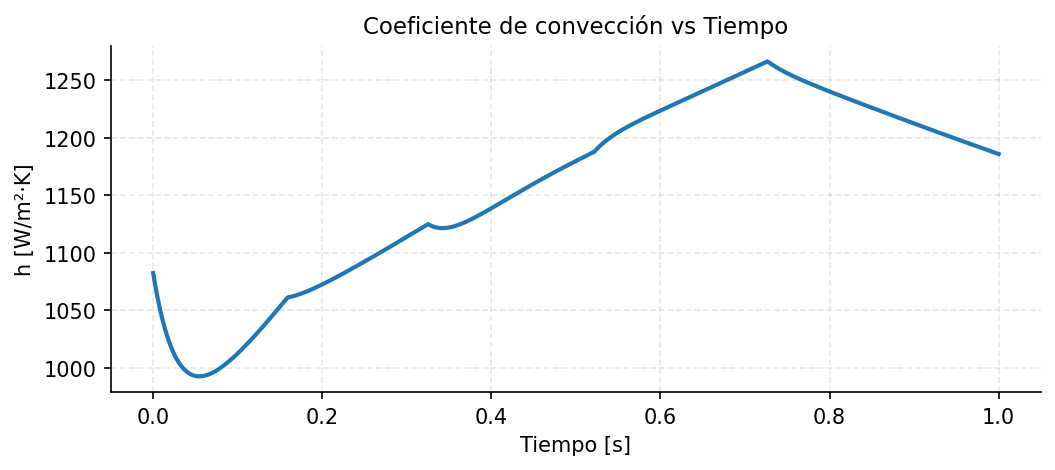

In [85]:
z_sol  = sol.y[0]
v_sol  = sol.y[1]
Tp_sol = sol.y[2]
t_sol  = sol.t

# Recalcular h en cada punto de tiempo
h_sol = np.zeros(len(t_sol))

for i in range(len(t_sol)):
    Tg    = T_g(z_sol[i])
    ug    = u_g(z_sol[i], Tg)
    v_rel = ug - v_sol[i]
    h_sol[i] = h_conv(v_rel, Tg)

# Graficar
plt.figure(figsize=(8,3))
plt.plot(t_sol, h_sol)
plt.xlabel('Tiempo [s]')
plt.ylabel('h [W/m²·K]')
plt.title('Coeficiente de convección vs Tiempo')
plt.show()

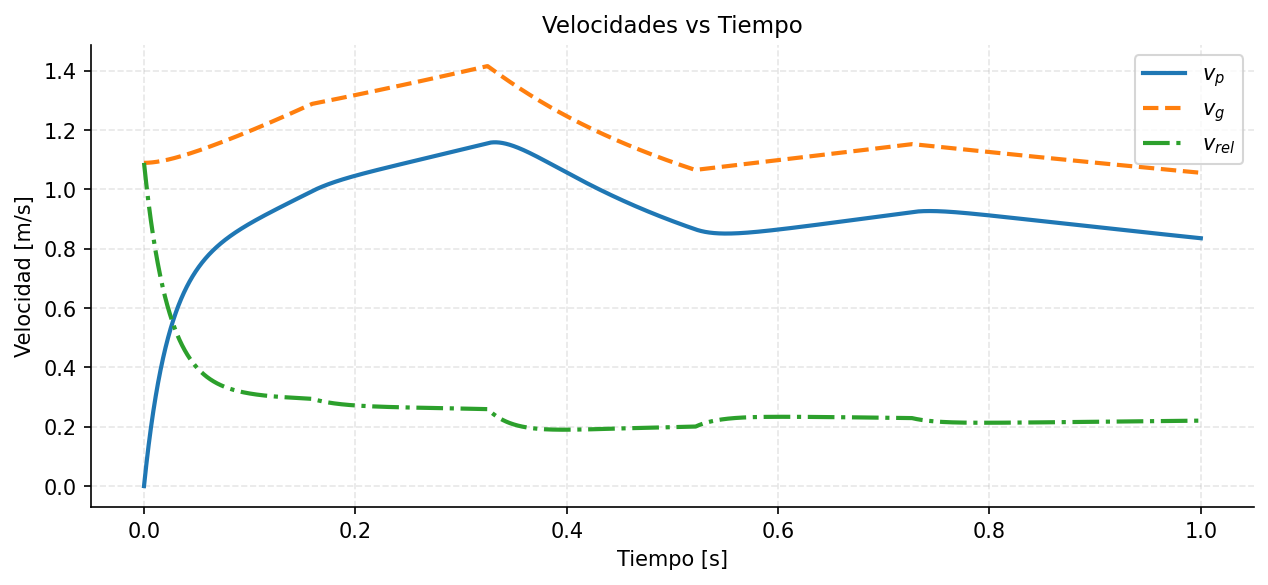

In [86]:
vg_sol   = np.zeros(len(t_sol))
vrel_sol = np.zeros(len(t_sol))

for i in range(len(t_sol)):
    Tg         = T_g(z_sol[i])
    vg_sol[i]  = u_g(z_sol[i], Tg)
    vrel_sol[i] = vg_sol[i] - v_sol[i]

# Graficar
plt.figure(figsize=(10,4))
plt.plot(t_sol, v_sol, label='$v_p$')
plt.plot(t_sol, vg_sol, label='$v_g$ ',ls='--')
plt.plot(t_sol, vrel_sol, label='$v_{rel}$',ls='-.')
plt.xlabel('Tiempo [s]')
plt.ylabel('Velocidad [m/s]')
plt.title('Velocidades vs Tiempo')
plt.legend()
plt.show()